# Creating MuData (from minimal-data Notebook)

In [14]:
import pandas as pd 
from scipy.sparse import csr_matrix

import pandas as pd                                                                                                             
import numpy as np                                                                                                            
from scipy import sparse                                                                                                        
from itertools import pairwise
import anndata as ad 
import mudata as md 

In [15]:
def get_unique_mappings(psm_table: pd.DataFrame, feature_level_names: list[str]) -> pd.DataFrame:
    """Get all unique mappings"""
    return psm_subset.loc[:, levels].drop_duplicates(subset=levels)
    

def adjacency_matrix_from_mapping(df: pd.DataFrame) -> pd.DataFrame:                                                            
    """Convert a mapping DataFrame to a sparse undirected adjacency matrix.                                                     
                                                                                                                                
    Each row creates edges between values in consecutive columns,                                                               
    representing hierarchical relationships.                                                   
    """                                                                                                                         
    all_values = pd.unique(df.values.ravel())                                                                                   
    value_to_idx = {v: i for i, v in enumerate(all_values)}                                                                     
    n = len(all_values)                                                                                                         
                                                                                                                                
    rows, cols = [], []                                                                                                         
    for _, row in df.iterrows():                                                                                                
        for v1, v2 in pairwise(row.values):                                                                                     
            i, j = value_to_idx[v1], value_to_idx[v2]                                                                           
            rows.extend([i, j])                                                                                                 
            cols.extend([j, i])                                                                                                 
                                                                                                                                
    adj = sparse.coo_matrix(                                                                                                    
        (np.ones(len(rows), dtype=np.float64), (rows, cols)),
        shape=(n, n),                                                                                                           
    ).tocsr()                                                                                                                     
    adj.data = np.ones_like(adj.data)  # collapse summed duplicates to 1                                                                                                                        
    return pd.DataFrame.sparse.from_spmatrix(adj, index=all_values, columns=all_values)     



# EXAMPLE DATA 
# Manually create a mapping and example data
var = pd.DataFrame(
    {
    "genes": [*(["gene0", "gene1", "gene1"]*2)], 
    "proteins": [*(["protein0", "protein1", "protein2"]*2)], 
    "precursors": [str(idx) for idx in range(1, 7)]
    },
    index=[str(idx) for idx in range(1, 7)]

)

levels = ["genes", "proteins", "precursors"]

psm_subset = pd.concat({"A": var, "B": var}).reset_index(level=0, names="sample")


precursors = ad.AnnData(
    X=np.zeros(shape=(5, 6)),
    obs=pd.DataFrame(index=[f"sample{idx}" for idx in range(5)]),
    var=var
)

proteins = ad.AnnData(
    X=np.zeros(shape=(5, 3)),
    obs=pd.DataFrame(index=[f"sample{idx}" for idx in range(5)]),
    var=pd.DataFrame(
        data={
            "proteins": ["protein0", "protein1", "protein2"],
            "genes": ["gene0", "gene1", "gene1"]
            },
        index=["protein0", "protein1", "protein2"])
)

genes = ad.AnnData(
    X=np.zeros(shape=(5, 2)),
    obs=pd.DataFrame(index=[f"sample{idx}" for idx in range(5)]),
    var=pd.DataFrame(index=["gene0", "gene1"])
)


# Create MUDATA (from manual dataset)
df = get_unique_mappings(psm_subset, feature_level_names=levels)
adjaceny = adjacency_matrix_from_mapping(df).sort_index(axis=0).sort_index(axis=1)


mdata = md.MuData(
    data={"precursors": precursors, "proteins": proteins, "genes": genes},
)
# Ensure that index ordering is correct
mdata.varp["feature_mapping"] = adjaceny.reindex(index=mdata.var_names, columns=mdata.var_names)

mdata

c:\Users\clemensb\AppData\Local\anaconda3\envs\astir_env\lib\site-packages\mudata\_core\mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
c:\Users\clemensb\AppData\Local\anaconda3\envs\astir_env\lib\site-packages\mudata\_core\mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 5 × 11
  varp:	'feature_mapping'
  3 modalities
    precursors:	5 x 6
      var:	'genes', 'proteins', 'precursors'
    proteins:	5 x 3
      var:	'proteins', 'genes'
    genes:	5 x 2

# Functionalities of pd.MultiIndex

In [16]:
def ix(s, key, level=None):
    """
    Wrapper around xs for MultiIndex querying.
    """
    if level is None:
        return s[key]
    return s.xs(key, level=level)

In [17]:
from typing import List, Union

def adjaceny_to_multi_index(adj: pd.DataFrame, feature_levels: dict[int, List[str]]) -> pd.DataFrame:
    """Convert adjacency matrix to a MultiIndex DataFrame."""

    level_names = list(feature_levels.keys())
    level_ids   = list(feature_levels.values())

    # extract edges between each consecutive level pair
    edge_dfs = []
    for i in range(len(level_ids) - 1):
        sources = level_ids[i]
        targets = level_ids[i + 1]
        sub = adj.loc[sources, targets]
        rows, cols = np.where(sub.values != 0)
        edge_dfs.append(pd.DataFrame({
            level_names[i]:     np.array(sources)[rows],
            level_names[i + 1]: np.array(targets)[cols],
        }))

    # edge_dfs into tuples
    merged = edge_dfs[0]
    for i in range(1, len(edge_dfs)):
        merged = merged.merge(edge_dfs[i], on=level_names[i])

    tuples = list(merged.itertuples(index=False, name=None))
    index  = pd.MultiIndex.from_tuples(tuples, names=level_names)

    return pd.Series(True, index=index)

In [18]:
precursor_ids = [c for c in adjaceny.index if str(c).isdigit()]
protein_ids   = [c for c in adjaceny.index if str(c).startswith("protein")]
gene_ids      = [c for c in adjaceny.index if str(c).startswith("gene")]

s = adjaceny_to_multi_index(adjaceny, {
    "precursor": precursor_ids,
    "protein":   protein_ids,
    "gene":      gene_ids,
})

In [19]:
s.head()

precursor  protein   gene 
1          protein0  gene0    True
2          protein1  gene1    True
3          protein2  gene1    True
4          protein0  gene0    True
5          protein1  gene1    True
dtype: bool

In [20]:
ix(s, "protein1", level="protein")

precursor  gene 
2          gene1    True
5          gene1    True
dtype: bool

In [21]:
ix(s, ("protein1", "gene1"), level=("protein", "gene"))

precursor
2    True
5    True
dtype: bool

In [22]:
def multi_index_to_adjacency(s: pd.Series) -> pd.DataFrame:
    """Convert MultiIndex Series to adjacency matrix.
    Examples
    --------
    >>> adj = multi_index_to_adjacency(s)
    """
    
    df = s.index.to_frame(index=False)
    
    # all unique nodes across all levels # To Do sort by feature level order (right now alphabetically sorted)
    all_nodes = pd.Index(sorted(pd.unique(df.values.ravel())))    
    adj = pd.DataFrame(0, index=all_nodes, columns=all_nodes)
    
    # fill in zeros
    level_names = s.index.names
    for i in range(len(level_names) - 1):
        src_col = level_names[i]
        tgt_col = level_names[i + 1]
        for _, row in df[[src_col, tgt_col]].drop_duplicates().iterrows():
            adj.loc[row[src_col], row[tgt_col]] = 1

    return adj + adj.T # for symmetric matrix

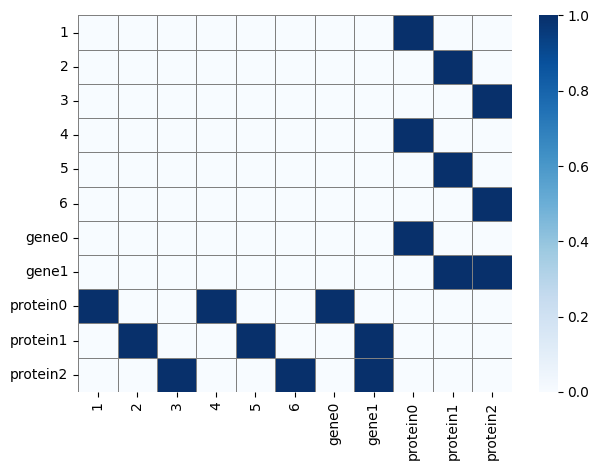

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
reconstructed_matrix = multi_index_to_adjacency(s)
sns.heatmap(reconstructed_matrix, cmap="Blues", linewidths=0.5, linecolor="grey")
plt.tight_layout()
plt.show()